# Simultaneous least squares fit

## Formulas

### Damped harmonic oscillator
Differential equation:
$$m \ddot x = -k x - \alpha \dot x$$
After dividing by $m$ one obtains
$$\ddot x + 2 \beta \dot x + \omega_0^2 x = 0; \quad \beta = \frac{\alpha}{2m}$$
In case of undercritical damping ($\beta < \omega_0$) the solution is :
$$x(t) = x_0 e^{- \beta t} \cos(\omega t + \varphi_0); \quad \omega = \sqrt{\omega_0^2 - \beta^2}$$
 
### Driven harmonic oscillator
Differential equation:
$$\ddot x + 2 \beta \dot x + \omega_0^2 x = K \cos \omega t; \quad K = \frac{f}{m}$$

Ansatz:
$$x(t) = A \cos (\omega t + \varphi) $$

Solution
$$A(\omega) = \frac{f/m}{\sqrt{(\omega^2 - \omega_0^2)^2 + 4 \beta^2 \omega^2}}$$

Phase shift between driving force and oscillator:
$$\tan \varphi = \frac{2 \beta \omega}{\omega^2 - \omega_0^2}, \quad -\pi \le \varphi \le 0$$

## Tasks

a) Fit the $x(t)$, $A(\omega)$ individually using the method of least squares

b) Fit $x(t)$ and $A(\omega)$ simultaneously. More generally, what is the reasoning behind such a combined fit?

Use the data generation provided in `S01_least_squares_02_generate_data.ipynb` and read it in as sketched below.

## Comments on Python's `iminuit`

The KIP service has iminuit version 1.3.8. Please note that the most recent version is $\geq2.0.0$ and that the [documentation](https://iminuit.readthedocs.io/en/stable/) applies to *that* version. Some backward-incompatible changes have been introduced, some of which changed some interfaces. For your tasks that mainly affects the `minuit.Minuit` constructor. The following shows the construction of a `Minuit` object for version 1.3.8 (in case you use the KIP service or a version $<2.0.0$) and $\geq2.0.0$ (in case you use another service implementing a higher version), respectively.
```python
from iminuit import Minuit

def func(par1, par2, ..., parN):
    return minimise_something(par1, par2, ..., parN)

# least squares method: errordef=1
# likelihood method: errordef=0.5
m = Minuit(func, par1=0.1, par2=0.1, ..., parN=0.1, errordef=1)
```

And this would be the equivalent workflow for versions >2.0.0
```python
from iminuit import Minuit

def func(par1, par2, ..., parN):
    return minimise_something(par1, par2, ..., parN)

# least squares method: errordef=Minuit.LEAST_SQUARES
# likelihood method: errordef=Minuit.LIKELIHOOD

# add errordef as an attribute of your defined minimisation function which will be checked for when optimised
func.errordef = Minuit.LEAST_SQUARES
m = Minuit(func, par1=0.1, par2=0.1, ..., parN=0.1)
```

Another (potenitally) Jupiter related *feature* is the fact that `m.migrad()`, `m.matrix()`, `m.minos()` etc. can yield a nice summary of the respective procedure. However, in order to show it, either of these methods (and potentially others in case you use them) have to be *the last line of a code cell*. If there is *anything* coming afterwards, the output will not be printed, hence, for anything that follows, it is recommended to start a new code cell.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit

## Read data

In [2]:
t_data, x_data, sigma_x = np.loadtxt('damped_free_oscillator.csv', delimiter=',', unpack=True)
omega_data, A_data, sigma_A, ph_data, sigma_ph = np.loadtxt('driven_oscillator.csv', 
                                                            delimiter=',', unpack=True)

## Solutions

### Fitting $x(t)$ and $A(\omega)$ Using the Least Squares Method
a) Fit the $x(t)$, $A(\omega)$ individually using the method of least squares


In [3]:
def x_harmonic_oscillator_underc_damp(t, params):
    x_0 = params[0]
    phi_0 = params[1]
    omega_0 = params[2]
    beta = params[3]
    if beta >= omega_0:
        return np.nan
    omega = np.sqrt(omega_0**2 - beta**2)
    return x_0 * np.exp(- beta * t) *  np.cos(omega * t + phi_0)

# takes two data sets and sums their square differences, weighted by error
def sum_square_residuals(
        data1: np.ndarray | float,
        data2: np.ndarray | float,
        data1_err: np.ndarray | float) -> float:
    square_residuals = (data1 - data2)**2 / data1_err**2
    return np.sum(square_residuals)

# calculates chi2_obs of a function on a data set for given parameters
def chi_square_of_function(data_x, data_y, data_y_error, fitcurve, *params):
    data2 = fitcurve(data_x, params)
    return sum_square_residuals(data_y, data2, data_y_error)

def plot_fitcurve(
        x, y, sigma_y,
        fitcurve, params, cov,
        x_lim: tuple,
        names: list
    ) -> None:
    # define points and evaluate model at them
    grid = np.linspace(x_lim[0], x_lim[1], 200)
    y_prediction = fitcurve(grid, params)

    # plot model curve
    plt.plot(grid, y_prediction, label = names[0], color = 'tab:orange')

    # # propagate errors for those points
    # J = fitcurve.jacobian(grid)
    # sigma = np.sqrt(np.diag(J @ cov @ J.T))
    # # create 1-sigma error band
    # lower = y_prediction - sigma
    # upper = y_prediction + sigma

    # plot data, model, error band
    plt.errorbar(x, y, yerr = sigma_y, linestyle='', marker='.', label = 'Data', color = 'tab:blue')
    # plt.fill_between(grid, lower, upper, alpha = 0.3, label = '1$\\sigma$-Error band')
    plt.xlim(x_lim)
    plt.xlabel(names[1])
    plt.ylabel(names[2])
    plt.title(names[3])
    plt.legend(loc = 'upper right')
    return

In [4]:
ind_data = t_data
dep_data = x_data
dep_data_error = sigma_x

def chi2_for_minuit(*params):
    return chi_square_of_function(ind_data, dep_data, dep_data_error, x_harmonic_oscillator_underc_damp, *params)

m = Minuit(chi2_for_minuit, *[1, 1, 1, 0.5])
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 30.15                      │             Nfcn = 1285              │
│ EDM = 3.34e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ x0   │  0.0979   │  0.0030   │            │            │         │         │       │
│ 1 │ x1   │  -0.033   │   0.034   │            │            │         │         │       │
│ 2 │ x2   │   4.027   │   0.014   │            │            │         │         │       │
│ 3 │ x3   │   0.282   │   0.014   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬─────────────────────────────────────┐
│    │       x0       x1       x2       x3 │
├────┼─────────────────────────────────────┤
│ x0 │ 8.74e-06    11e-6    -2e-6    27e-6 │
│ x1 │    11e-6  0.00118 -0.36e-3  0.04e-3 │
│ x2 │    -2e-6 -0.36e-3 0.000208       -0 │
│ x3 │    27e-6  0.04e-3       -0 0.000181 │
└────┴─────────────────────────────────────┘

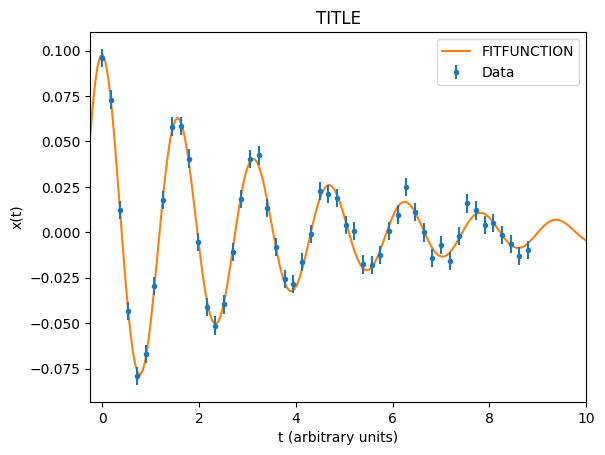

In [5]:
names = ['FITFUNCTION', r't (arbitrary units)', r'x(t)', 'TITLE']
x_lim = (-0.25, 10)
params = np.asarray(m.values)
cov = np.asarray(m.covariance)

plot_fitcurve(
    ind_data, dep_data, dep_data_error,
    x_harmonic_oscillator_underc_damp, params, cov,
    x_lim,
    names
)

In [ ]:
def A_

ind_data = omega_data
dep_data = A_data
dep_data_error = sigma_A

def chi2_for_minuit(*params):
    return chi_square_of_function(ind_data, dep_data, dep_data_error, x_harmonic_oscillator_underc_damp, *params)

m = Minuit(chi2_for_minuit, *[1, 1, 1, 0.5])
m.migrad()

/var/folders/lh/p9mw7lvd7bx4lm61ckr44rd80000gn/T/ipykernel_6457/223494790.py:8: RuntimeWarning: invalid value encountered in sqrt
  omega = np.sqrt(omega_0**2 - beta**2)
/var/folders/lh/p9mw7lvd7bx4lm61ckr44rd80000gn/T/ipykernel_6457/223494790.py:9: RuntimeWarning: overflow encountered in exp
  return x_0 * np.exp(- beta * t) *  np.cos(omega * t + phi_0)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 363.1                      │              Nfcn = 449              │
│ EDM = 2.01e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ x0   │   1.31    │   0.24    │            │            │         │         │       │
│ 1 │ x1   │   8.14    │   0.07    │            │            │         │         │       │
│ 2 │ x2   │   1.241   │   0.022   │            │            │         │         │       │
│ 3 │ x3   │   0.74    │   0.04    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬─────────────────────────────────────┐
│    │       x0       x1       x2       x3 │
├────┼─────────────────────────────────────┤
│ x0 │   0.0603    0.005   4.2e-3   0.0107 │
│ x1 │    0.005  0.00427  -0.5e-3   0.0009 │
│ x2 │   4.2e-3  -0.5e-3 0.000503   0.7e-3 │
│ x3 │   0.0107   0.0009   0.7e-3   0.0019 │
└────┴─────────────────────────────────────┘

b) Fit $x(t)$ and $A(\omega)$ simultaneously. More generally, what is the reasoning behind such a combined fit?

Use the data generation provided in `S01_least_squares_02_generate_data.ipynb` and read it in as sketched below.